run this command in terminal before running this code:

best practise: first create a .venv(a virtual environment) refer web to create this and then actiate the .venv and run this command.

pip install pandas numpy scikit-learn tensorflow matplotlib seaborn openpyxl

Block 1: Multi-Class LSTM & Performance Metrics

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow as tf

import os
import random



# 1. Clear any hidden Keras memory
tf.keras.backend.clear_session()

# 2. Lock all random seeds for perfect reproducibility
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. STATIONARY & REGIME-AWARE FEATURE ENGINEERING
# ==========================================

def add_stationary_features(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    df['Returns'] = df['Close'].pct_change()
    
    df['Dist_SMA10'] = (df['Close'] / df['Close'].rolling(window=10).mean()) - 1
    df['Dist_SMA50'] = (df['Close'] / df['Close'].rolling(window=50).mean()) - 1
    df['Dist_SMA200'] = (df['Close'] / df['Close'].rolling(window=200).mean()) - 1
    
    # NEW MACRO REGIME FEATURE: 20-Day Slope of the 200-Day SMA
    df['SMA_200_Slope'] = df['Close'].rolling(window=200).mean().pct_change(periods=20)
    
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    df['True_Range'] = np.max(ranges, axis=1)
    df['ATR_Norm'] = df['True_Range'].rolling(window=14).mean() / df['Close']
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df['RSI'] = 100 - (100 / (1 + (gain / loss)))
    df['Volatility'] = df['Returns'].rolling(window=20).std()
    
    return df

# ==========================================
# 2. MULTI-CLASS LABELING (0=Hold, 1=Buy, 2=Sell)
# ==========================================

def apply_multiclass_barriers(df, horizon=20, pt_multiplier=2.5, sl_multiplier=2.0):
    labels = np.zeros(len(df)) # Default to Hold (0)
    closes, highs, lows = df['Close'].values, df['High'].values, df['Low'].values
    
    atrs = df['True_Range'].rolling(window=14).mean().bfill().values 
    
    for i in range(len(df) - horizon):
        upper_barrier = closes[i] + (atrs[i] * pt_multiplier)
        lower_barrier = closes[i] - (atrs[i] * sl_multiplier)
        
        for j in range(1, horizon + 1):
            future_idx = i + j
            if highs[future_idx] >= upper_barrier:
                labels[i] = 1 # Buy
                break
            elif lows[future_idx] <= lower_barrier:
                labels[i] = 2 # Sell
                break
                
    df['Target'] = labels
    return df

# ==========================================
# 3. LSTM DATA PREPARATION
# ==========================================

TIME_STEPS = 30 

train_data = pd.read_excel('BBD_train.xlsx')

if 'Buy' in train_data.columns:
    train_data = train_data.drop(columns=['Buy', 'Sell'], errors='ignore')

train_data = add_stationary_features(train_data)

# Ensuring barriers are wide enough to keep the Hold class alive
train_data = apply_multiclass_barriers(train_data, horizon=20, pt_multiplier=2.5, sl_multiplier=2.0)
train_data = train_data.dropna().reset_index(drop=True)

# Added our new Regime feature
feature_cols = ['Returns', 'Dist_SMA50', 'Dist_SMA200', 'ATR_Norm', 'RSI', 'SMA_200_Slope']
scaler = StandardScaler() 
scaled_features = scaler.fit_transform(train_data[feature_cols])

def create_sequences(features, labels, time_steps):
    X, y = [], []
    for i in range(len(features) - time_steps):
        X.append(features[i:(i + time_steps)])
        y.append(labels.iloc[i + time_steps])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_features, train_data['Target'], TIME_STEPS)

split_idx = int(len(X_seq) * 0.8)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_eval, y_eval = X_seq[split_idx:], y_seq[split_idx:]

eval_df = train_data.iloc[split_idx + TIME_STEPS:].copy().reset_index(drop=True)

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))

# ==========================================
# 4. REGULARIZED LSTM MODEL TRAINING
# ==========================================

def build_multiclass_lstm(input_shape):
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=input_shape, kernel_regularizer=l2(0.005)),
        BatchNormalization(), 
        Dropout(0.4),
        
        LSTM(16, kernel_regularizer=l2(0.005)),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(8, activation='relu', kernel_regularizer=l2(0.005)),
        Dense(3, activation='softmax') 
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

print("Training Unified Multi-Class LSTM...")
lstm_model = build_multiclass_lstm((TIME_STEPS, len(feature_cols)))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1, class_weight=class_weights_dict, callbacks=[early_stop])

prob_train = lstm_model.predict(X_train)
pred_train = np.argmax(prob_train, axis=1)

print("\n" + "="*50)
print("📊 INITIAL TRAINING SET METRICS (Multi-Class)")
print("="*50)
print(f"Overall Accuracy: {accuracy_score(y_train, pred_train):.4f}\n")
print(classification_report(y_train, pred_train, target_names=['Hold (0)', 'Buy (1)', 'Sell (2)'], zero_division=0))


Training Unified Multi-Class LSTM...
Epoch 1/50


e:\MBS files\SEM2\Big Data Application to Business\project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4260 - loss: 1.6580
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4330 - loss: 1.4501
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4429 - loss: 1.3610
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4512 - loss: 1.3107
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4421 - loss: 1.2661
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4475 - loss: 1.2294
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4715 - loss: 1.1888
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4773 - loss: 1.1655
Epoch 9/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5045 - loss: 1.1278
Epoch 10/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5161 - loss: 1.1092
Epoch 11/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5120 - loss: 1.0811
Epoch 12/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5252 - loss: 1.0651


block 2: back-testing using training dataset

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 EVALUATION SET METRICS (Multi-Class)
Overall Accuracy: 0.3223
Macro F1 Score:   0.2935
Mean Sq. Error:   1.0843

              precision    recall  f1-score   support

    Hold (0)       0.17      0.23      0.20        95
     Buy (1)       0.32      0.59      0.41       196
    Sell (2)       0.50      0.18      0.27       314

    accuracy                           0.32       605
   macro avg       0.33      0.33      0.29       605
weighted avg       0.39      0.32      0.30       605


🚀 FINANCIAL ANALYTICS (Eval Set)
Final Portfolio Value: $2976.11
Total Net Profit:      $-23.89
--------------------------------------------------
Total Trades:          33
Win Rate:              36.4%
Cumulative Trade Rev:  $-268.07
Avg Revenue per Trade: $-8.12
Avg Holding Period:    16.2 days
--------------------------------------------------
EXIT STATS:
- Take Profit: 6
- Dynamic ATR Stop: 20
- AI Sell Signal: 7


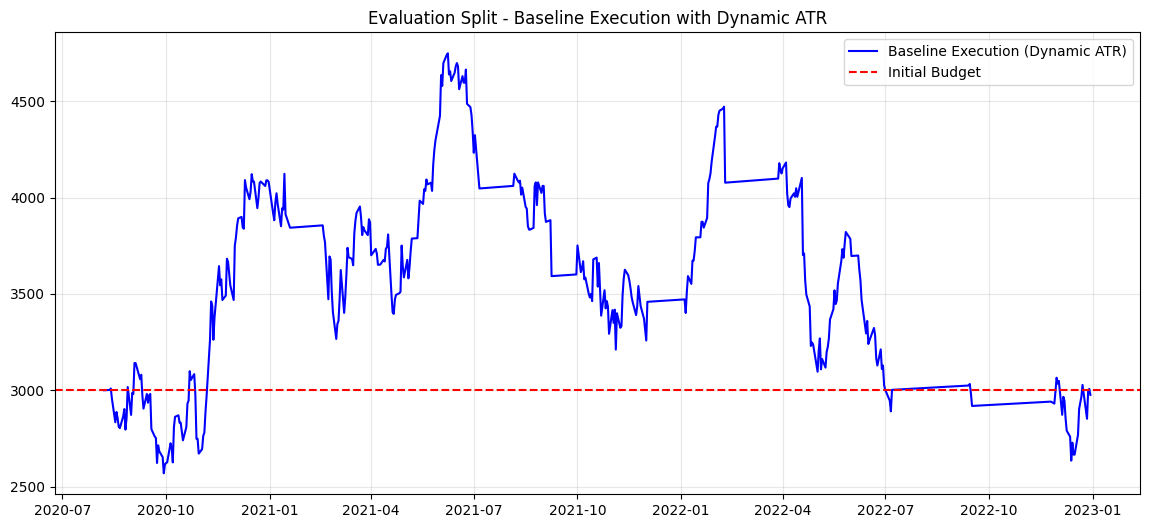

In [2]:
# ==========================================
# 5. AGGRESSIVE EVALUATION SET (DYNAMIC ATR STOP)
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, mean_squared_error
import numpy as np
import pandas as pd

INITIAL_BUDGET = 3000.0
DAILY_INTEREST_RATE = 0.04 / 365.0

POSITION_SIZE = 1.0          
TAKE_PROFIT_PCT = 0.15       
ATR_MULTIPLIER = 2.0         

prob_eval = lstm_model.predict(X_eval)
pred_eval = np.argmax(prob_eval, axis=1)

# Calculate additional ML metrics
macro_f1_eval = f1_score(y_eval, pred_eval, average='macro')
mse_eval = mean_squared_error(y_eval, pred_eval)

print("\n" + "="*50)
print("📊 EVALUATION SET METRICS (Multi-Class)")
print("="*50)
print(f"Overall Accuracy: {accuracy_score(y_eval, pred_eval):.4f}")
print(f"Macro F1 Score:   {macro_f1_eval:.4f}")
print(f"Mean Sq. Error:   {mse_eval:.4f}\n")
print(classification_report(y_eval, pred_eval, target_names=['Hold (0)', 'Buy (1)', 'Sell (2)'], zero_division=0))

eval_df['Prob_Buy'] = prob_eval[:, 1]
eval_df['Prob_Sell'] = prob_eval[:, 2]

cash, shares = INITIAL_BUDGET, 0
portfolio_values, trades = [], []
current_trade_entry_price, highest_price_since_entry, current_trade_entry_date = 0, 0, None

for i in range(len(eval_df)):
    row = eval_df.iloc[i]
    current_date, close_price = row['Date'], row['Close']
    
    if i > 0 and cash > 0:
        days_passed = (current_date - eval_df.iloc[i-1]['Date']).days
        cash *= ((1 + DAILY_INTEREST_RATE) ** days_passed)
        
    if shares > 0:
        days_held = (current_date - current_trade_entry_date).days
        cur_ret = (close_price - current_trade_entry_price) / current_trade_entry_price
        highest_price_since_entry = max(highest_price_since_entry, close_price)
        
        dynamic_stop_pct = row['ATR_Norm'] * ATR_MULTIPLIER
        dynamic_stop_pct = max(0.02, min(dynamic_stop_pct, 0.12)) 
        
        trailing_stop_price = highest_price_since_entry * (1 - dynamic_stop_pct)
        
        exit_reason = ""
        if cur_ret >= TAKE_PROFIT_PCT: exit_reason = "Take Profit"
        elif close_price <= trailing_stop_price: exit_reason = "Dynamic ATR Stop"
        elif pred_eval[i] == 2: exit_reason = "AI Sell Signal" 
            
        if exit_reason:
            rev = (close_price - current_trade_entry_price) * shares
            trades.append({'revenue': rev, 'return': cur_ret*100, 'duration': days_held, 'reason': exit_reason})
            cash += shares * close_price
            shares = 0
            
    if shares == 0 and cash > 0 and pred_eval[i] == 1: 
        shares = (cash * POSITION_SIZE) / close_price
        cash -= (cash * POSITION_SIZE)
        current_trade_entry_price = highest_price_since_entry = close_price
        current_trade_entry_date = current_date
        
    portfolio_values.append(cash + (shares * close_price))

eval_df['Portfolio_Value'] = portfolio_values
final_val = eval_df['Portfolio_Value'].iloc[-1]
total_profit = final_val - INITIAL_BUDGET

# Calculate Advanced Trading Metrics
win_rate = sum(1 for t in trades if t['revenue'] > 0) / len(trades) * 100 if trades else 0
cum_rev = sum(t['revenue'] for t in trades) if trades else 0
avg_rev = cum_rev / len(trades) if trades else 0
avg_hold = sum(t['duration'] for t in trades) / len(trades) if trades else 0

print("\n" + "="*50)
print(f"🚀 FINANCIAL ANALYTICS (Eval Set)")
print("="*50)
print(f"Final Portfolio Value: ${final_val:.2f}")
print(f"Total Net Profit:      ${total_profit:.2f}")
print("-" * 50)
print(f"Total Trades:          {len(trades)}")
print(f"Win Rate:              {win_rate:.1f}%")
print(f"Cumulative Trade Rev:  ${cum_rev:.2f}")
print(f"Avg Revenue per Trade: ${avg_rev:.2f}")
print(f"Avg Holding Period:    {avg_hold:.1f} days")
print("-" * 50)
print("EXIT STATS:")
for reason in ["Take Profit", "Dynamic ATR Stop", "AI Sell Signal"]:
    count = sum(1 for t in trades if t['reason'] == reason)
    print(f"- {reason}: {count}")
print("="*50)

plt.figure(figsize=(14, 6))
plt.plot(eval_df['Date'], eval_df['Portfolio_Value'], color='blue', label='Baseline Execution (Dynamic ATR)')
plt.axhline(y=INITIAL_BUDGET, color='red', linestyle='--', label='Initial Budget')
plt.title('Evaluation Split - Baseline Execution with Dynamic ATR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

BLOCK 3:



Starting STRICT Inference on Unseen Testing Dataset...
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📊 UNSEEN TEST SET METRICS (Static Inference)
Overall Accuracy: 0.4511
Macro F1 Score:   0.4278
Mean Sq. Error:   0.9130

              precision    recall  f1-score   support

    Hold (0)       0.27      0.49      0.35        84
     Buy (1)       0.46      0.32      0.38       222
    Sell (2)       0.56      0.55      0.56       246

    accuracy                           0.45       552
   macro avg       0.43      0.46      0.43       552
weighted avg       0.48      0.45      0.45       552


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
 FINAL COMPETITION SCORE: $4740.41
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
Total Net Profit:      $1740.41
Vs 4% Benchmark:       +44.67%
----------------------------------------
Total Trades:          15
Win Rate:              60.0%
Cumulative Trade Rev:  $1543.03
Avg Revenue per Trade: $102.87
Avg Holding Period:    16.3 days
----------------------------------------
EXIT STATS:
- Take Profit: 2

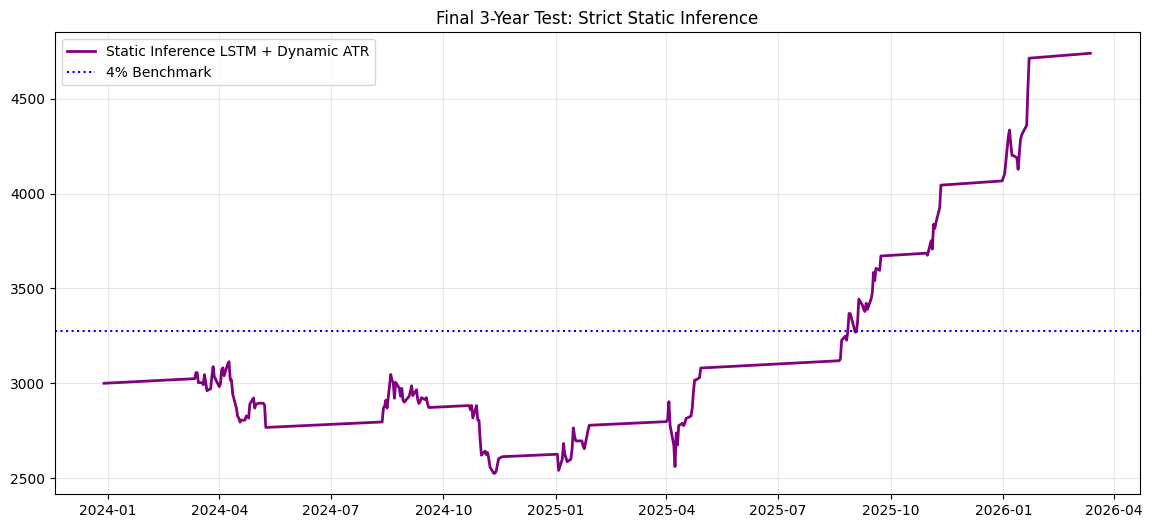


Exporting final results to Excel...
Successfully saved Final_BBD_Results.xlsx to your local directory.


In [3]:
# ==========================================
# 6. FINAL UNSEEN TEST (STRICT INFERENCE ONLY)
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, mean_squared_error
import numpy as np
import pandas as pd

print("\nStarting STRICT Inference on Unseen Testing Dataset...")

# 1. Prepare Test Data
test_data = pd.read_excel('BBD_test.xlsx')
original_cols = test_data.columns.tolist()

if 'Buy' in test_data.columns: 
    test_data = test_data.drop(columns=['Buy', 'Sell', 'Target'], errors='ignore')

test_data = add_stationary_features(test_data)
# We generate the barriers purely to print the evaluation metrics for your report
test_data = apply_multiclass_barriers(test_data, horizon=20, pt_multiplier=2.5, sl_multiplier=2.0) 
test_data = test_data.dropna().reset_index(drop=True)

# WE STRICTLY USE THE ALREADY-FITTED SCALER FROM BLOCK 1
scaled_test = scaler.transform(test_data[feature_cols])
X_test_seq, y_test_true = create_sequences(scaled_test, test_data['Target'], TIME_STEPS)
test_df_final = test_data.iloc[TIME_STEPS:].copy().reset_index(drop=True)

# 2. STRICT INFERENCE: PURE PREDICTION (ZERO RETRAINING)
prob_test_final = lstm_model.predict(X_test_seq)
pred_test_final = np.argmax(prob_test_final, axis=1)

macro_f1_test = f1_score(y_test_true, pred_test_final, average='macro')
mse_test = mean_squared_error(y_test_true, pred_test_final)

print("\n" + "="*50)
print("📊 UNSEEN TEST SET METRICS (Static Inference)")
print("="*50)
print(f"Overall Accuracy: {accuracy_score(y_test_true, pred_test_final):.4f}")
print(f"Macro F1 Score:   {macro_f1_test:.4f}")
print(f"Mean Sq. Error:   {mse_test:.4f}\n")
print(classification_report(y_test_true, pred_test_final, target_names=['Hold (0)', 'Buy (1)', 'Sell (2)'], zero_division=0))

# 3. Execute Final Strategy & Track Trades for Excel
cash, shares = INITIAL_BUDGET, 0
portfolio_values, final_trades = [], []
current_trade_entry_price, highest_price_since_entry, current_trade_entry_date = 0, 0, None

POSITION_SIZE = 1.0          
TAKE_PROFIT_PCT = 0.15   
ATR_MULTIPLIER = 2.0    

# Initialize strictly named columns requested by Professor
# Using 'None' ensures the days between trades remain perfectly blank in Excel
test_df_final['Buy'] = None
test_df_final['Sell'] = None

for i in range(len(test_df_final)):
    row = test_df_final.iloc[i]
    current_date, close_price = row['Date'], row['Close']
    
    if i > 0 and cash > 0:
        days_passed = (current_date - test_df_final.iloc[i-1]['Date']).days
        cash *= ((1 + DAILY_INTEREST_RATE) ** days_passed)
        
    # --- EXIT LOGIC ---
    if shares > 0:
        cur_ret = (close_price - current_trade_entry_price) / current_trade_entry_price
        highest_price_since_entry = max(highest_price_since_entry, close_price)
        
        dynamic_stop_pct = row['ATR_Norm'] * ATR_MULTIPLIER
        dynamic_stop_pct = max(0.02, min(dynamic_stop_pct, 0.12)) 
        
        trailing_stop_price = highest_price_since_entry * (1 - dynamic_stop_pct)
        
        exit_reason = ""
        if cur_ret >= TAKE_PROFIT_PCT: exit_reason = "Take Profit"
        elif close_price <= trailing_stop_price: exit_reason = "Dynamic ATR Stop"
        elif pred_test_final[i] == 2: exit_reason = "AI Sell Signal" 
            
        if exit_reason:
            final_trades.append({'revenue': (close_price - current_trade_entry_price)*shares, 'reason': exit_reason, 'duration': (current_date - current_trade_entry_date).days})
            cash += shares * close_price
            shares = 0
            
            # Record exact sell day with binary 1
            test_df_final.at[i, 'Sell'] = 1
            
    # --- ENTRY LOGIC ---
    if shares == 0 and cash > 0 and pred_test_final[i] == 1: 
        shares = (cash * POSITION_SIZE) / close_price
        cash -= (cash * POSITION_SIZE)
        current_trade_entry_price = highest_price_since_entry = close_price
        current_trade_entry_date = current_date
        
        # Record exact buy day with binary 1
        test_df_final.at[i, 'Buy'] = 1
        
    portfolio_values.append(cash + (shares * close_price))

test_df_final['Portfolio_Value'] = portfolio_values

final_score = test_df_final['Portfolio_Value'].iloc[-1]
bench = INITIAL_BUDGET * ((1 + DAILY_INTEREST_RATE) ** (test_df_final['Date'].iloc[-1] - test_df_final['Date'].iloc[0]).days)
total_profit = final_score - INITIAL_BUDGET

win_rate_final = sum(1 for t in final_trades if t['revenue'] > 0) / len(final_trades) * 100 if final_trades else 0
cum_rev_final = sum(t['revenue'] for t in final_trades) if final_trades else 0
avg_rev_final = cum_rev_final / len(final_trades) if final_trades else 0
avg_hold_final = sum(t['duration'] for t in final_trades) / len(final_trades) if final_trades else 0

print("\n" + "🏆" * 20)
print(f" FINAL COMPETITION SCORE: ${final_score:.2f}")
print("🏆" * 20)
print(f"Total Net Profit:      ${total_profit:.2f}")
print(f"Vs 4% Benchmark:       {((final_score/bench)-1)*100:+.2f}%")
print("-" * 40)
print(f"Total Trades:          {len(final_trades)}")
print(f"Win Rate:              {win_rate_final:.1f}%")
print(f"Cumulative Trade Rev:  ${cum_rev_final:.2f}")
print(f"Avg Revenue per Trade: ${avg_rev_final:.2f}")
print(f"Avg Holding Period:    {avg_hold_final:.1f} days")
print("-" * 40)
print("EXIT STATS:")
for reason in ["Take Profit", "Dynamic ATR Stop", "AI Sell Signal"]:
    count = sum(1 for t in final_trades if t['reason'] == reason)
    print(f"- {reason}: {count}")
print("=" * 40)

plt.figure(figsize=(14, 6))
plt.plot(test_df_final['Date'], test_df_final['Portfolio_Value'], label='Static Inference LSTM + Dynamic ATR', color='purple', linewidth=2)
plt.axhline(y=bench, color='blue', linestyle=':', label='4% Benchmark')
plt.title('Final 3-Year Test: Strict Static Inference')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 7. EXPORT EXECUTION LOG TO EXCEL
# ==========================================
print("\nExporting final results to Excel...")
export_filename = 'Final_BBD_Results.xlsx'

# Ensure exactly the columns from original data + 'Buy' and 'Sell'
base_cols = [c for c in original_cols if c in test_df_final.columns and c not in ['Buy', 'Sell', 'Target']]
export_cols = base_cols + ['Buy', 'Sell']

test_df_final[export_cols].to_excel(export_filename, index=False)

try:
    from google.colab import files
    files.download(export_filename)
    print(f"Successfully downloaded {export_filename}")
except ImportError:
    print(f"Successfully saved {export_filename} to your local directory.")